In [1]:
# Imports and Setup
import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd

import seaborn as sns

import matplotlib
matplotlib.use('Agg')  # Ensure non-GUI backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is imported

# Ensure inline plotting on Kaggle
%matplotlib inline

# Scikit-learn modules for modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("data/Ecommerce_Consumer_Behavior_Analysis_Data.csv") 

print('Data loaded successfully. Shape:', df.shape)

Data loaded successfully. Shape: (1000, 28)


In [3]:
# Data Cleaning and Preprocessing

# Convert Purchase_Amount from string to numeric
# Some datasets include currency symbols or commas, so we remove non-numeric characters
if 'Purchase_Amount' in df.columns:
    df['Purchase_Amount'] = pd.to_numeric(
        df['Purchase_Amount'].replace({r'[^0-9\.]': ''}, regex=True),
        errors='coerce'
    )

# Convert Time_of_Purchase to datetime if possible (the column is originally a string)
if 'Time_of_Purchase' in df.columns:
    df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], errors='coerce')

# Inspecting missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

# For this analysis we will drop rows with missing Purchase_Amount or Time_of_Purchase
df.dropna(subset=['Purchase_Amount', 'Time_of_Purchase'], inplace=True)

Missing values in each column:
Social_Media_Influence    247
Engagement_with_Ads       256
dtype: int64


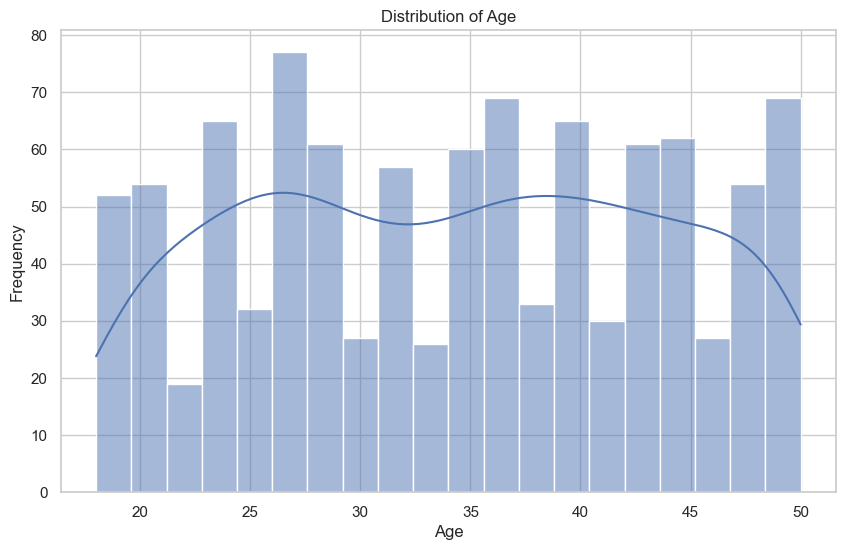

In [4]:
# Exploratory Data Analysis (EDA)

## Histogram for Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

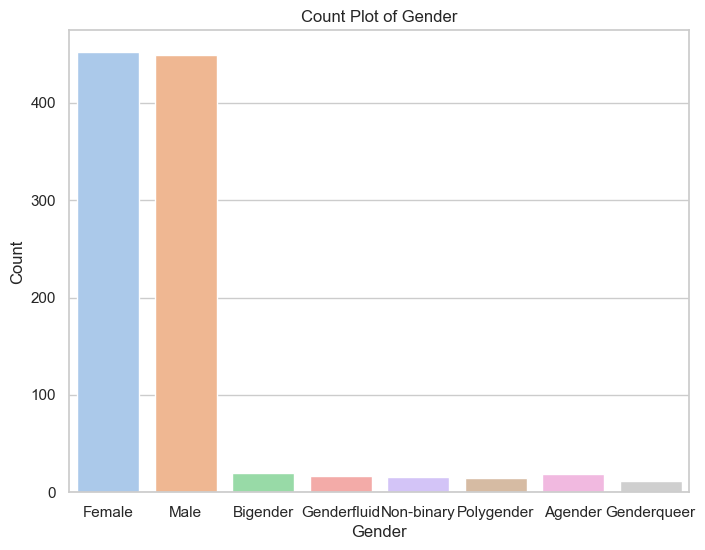

In [5]:
## Count plot for Gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Count Plot of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

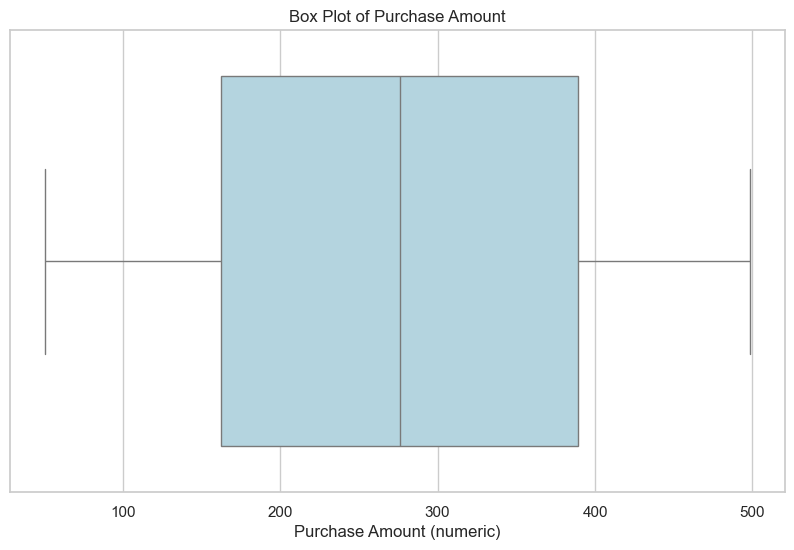

In [6]:
## Box plot for Purchase_Amount (after conversion)
if 'Purchase_Amount' in df.columns and pd.api.types.is_numeric_dtype(df['Purchase_Amount']):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Purchase_Amount', data=df, color='lightblue')
    plt.title('Box Plot of Purchase Amount')
    plt.xlabel('Purchase Amount (numeric)')
    plt.show()

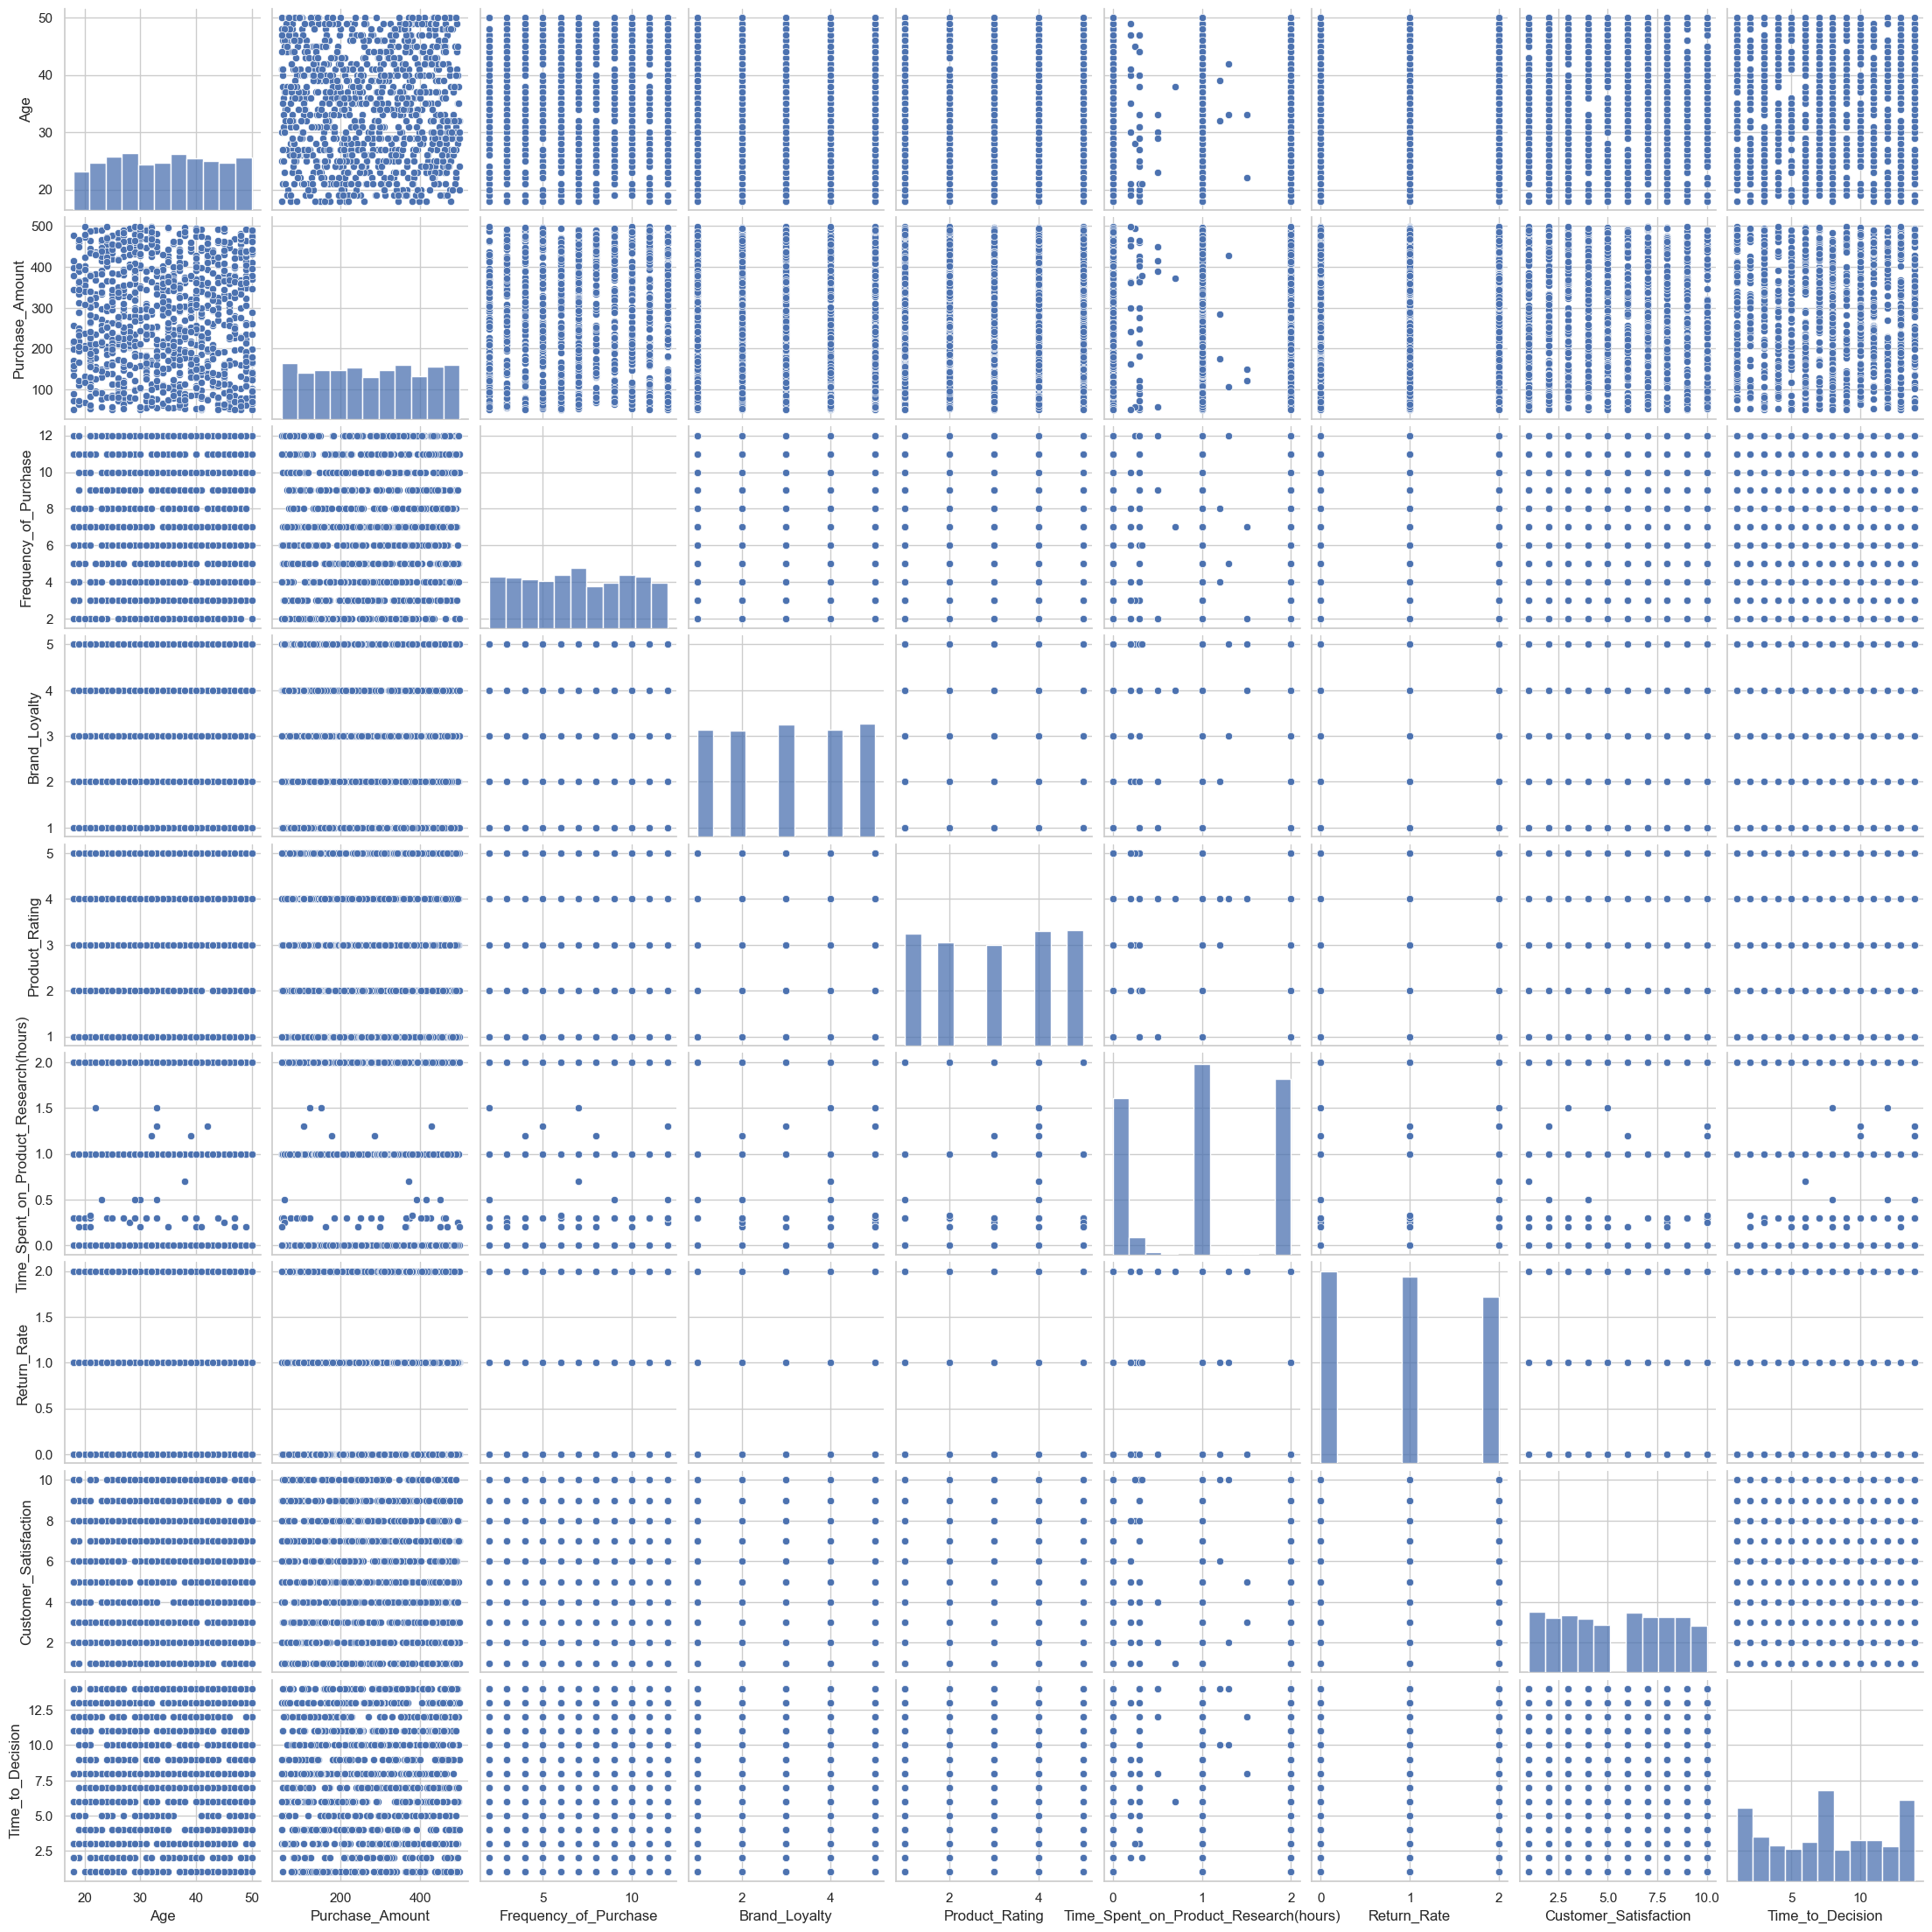

In [7]:
## Pair plot for a few numeric variables (if sufficient numeric columns exist)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    sns.pairplot(numeric_df)
    plt.show()

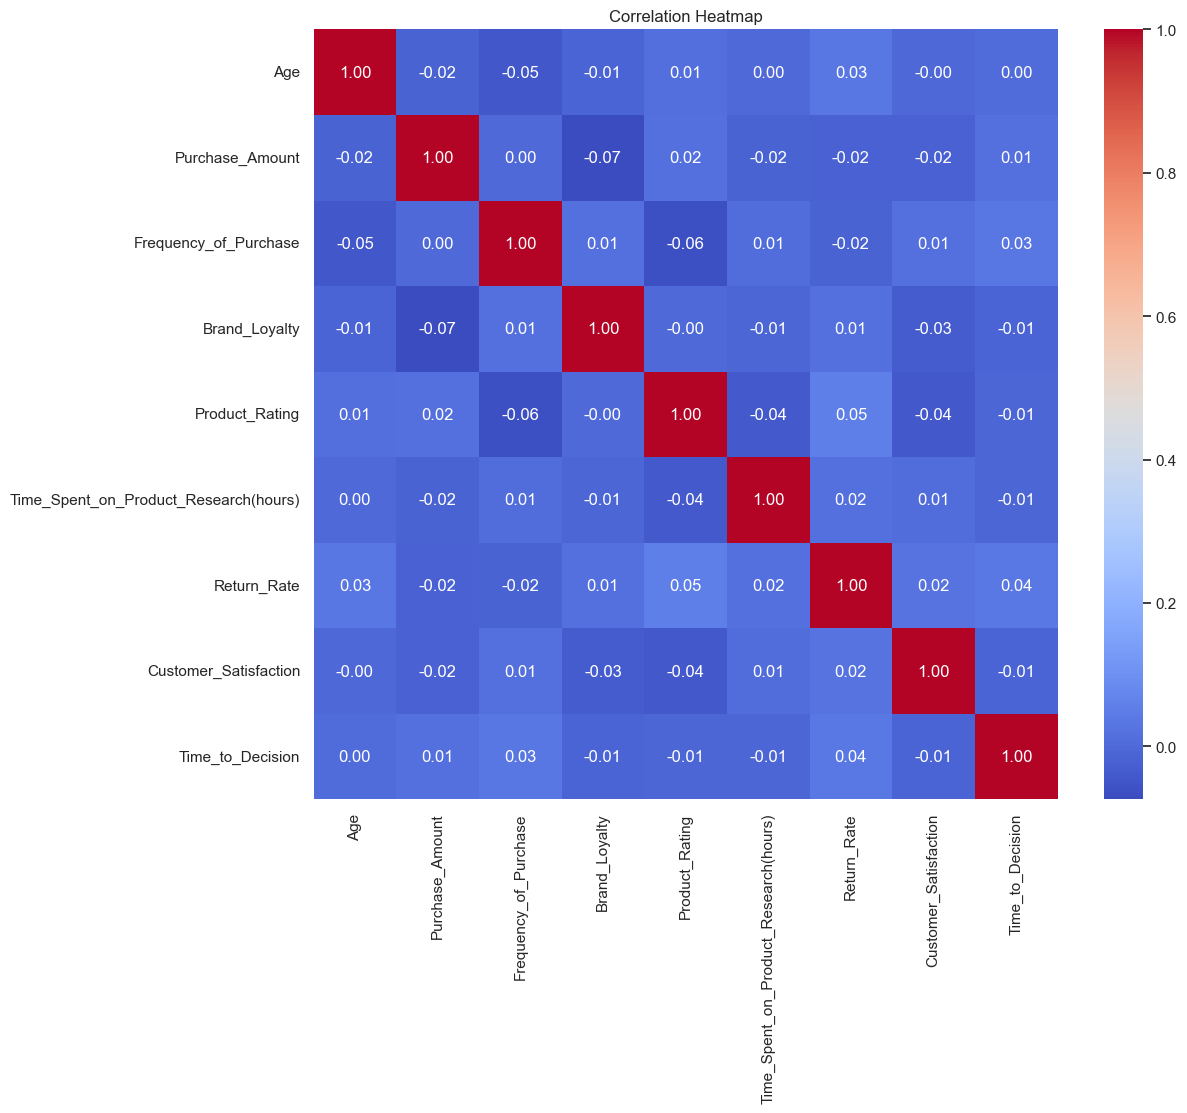

In [8]:
## Correlation heatmap (only if four or more numeric columns are present)
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

In [6]:
# First, drop rows with missing target
df_model = df.dropna(subset=['Customer_Satisfaction']).copy()

In [7]:
# Define target and features
target = 'Customer_Satisfaction'

In [8]:
drop_columns = ['Customer_ID', target]
features = df_model.drop(columns=drop_columns, errors='ignore')

In [9]:
numeric_features = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = features.select_dtypes(exclude=[np.number]).columns.tolist()

In [10]:
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['Age', 'Frequency_of_Purchase', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Return_Rate', 'Time_to_Decision']
Categorical features: ['Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Amount', 'Purchase_Channel', 'Social_Media_Influence', 'Discount_Sensitivity', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent', 'Shipping_Preference']


In [11]:
X = features.copy()
y = df_model[target]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Build preprocessing pipelines for both numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [14]:
# Create a pipeline that combines the preprocessor with a classifier
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [15]:
# Train the model
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# Predict on test set
y_pred = clf.predict(X_test)

In [19]:
# Evaluate the model
acc = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', acc)

Prediction Accuracy: 0.105


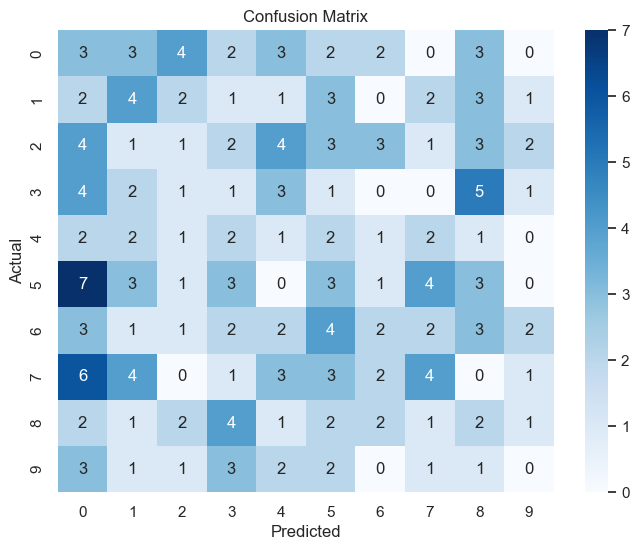

In [20]:
# Confusion Matrix (visualized using seaborn heatmap)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
